In [42]:
import pandas as pd

df = pd.read_csv("../data/archive/players_data_light-2024_2025.csv")
pd.set_option('display.max_columns', None)

In [43]:
qualified = df[df['Min']>1000]

qualified['G_minus_xG'] = qualified['Gls'] - qualified['xG']

C:\Users\Timothy\AppData\Local\Temp\ipykernel_11580\2779835231.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  qualified['G_minus_xG'] = qualified['Gls'] - qualified['xG']


In [44]:
qualified = qualified.sort_values(
    "G_minus_xG",
    ascending=False
)

qualified[ ['Player', 'Gls', 'xG', 'G_minus_xG'] ].head(5)

,Player,Gls,xG,G_minus_xG
2369,Patrik Schick,21,12.7,8.3
1693,Bryan Mbeumo,20,12.3,7.7
2787,Chris Wood,20,13.4,6.6
637,Matheus Cunha,15,8.6,6.4
2088,Ayoze Pérez,19,12.7,6.3


In [45]:
qualified[ ['Player', 'Gls', 'xG', 'G_minus_xG'] ].tail(5)

,Player,Gls,xG,G_minus_xG
18,Tammy Abraham,3,7.1,-4.1
66,Maghnes Akliouche,5,9.2,-4.2
838,Breel Embolo,6,10.8,-4.8
866,Abde Ezzalzouli,2,8.0,-6.0
823,Hugo Ekitike,15,21.6,-6.6


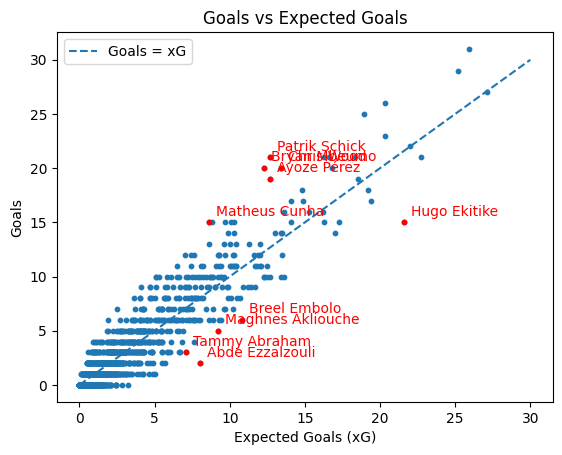

In [46]:
import matplotlib.pyplot as plt

plt.scatter(
    qualified["xG"],
    qualified["Gls"],
    s = 10
)

plt.plot(
    [0, 30],
    [0, 30],
    label = "Goals = xG",
    linestyle = '--'
)

plt.xlabel("Expected Goals (xG)")
plt.ylabel("Goals")
plt.title("Goals vs Expected Goals")

plt.legend()

top5 = qualified.head(5)
bottom5 = qualified.tail(5)

for _, row in top5.iterrows():
    plt.annotate(
        row["Player"],
        (row["xG"], row["Gls"]),
        xytext=(5,5),
        textcoords="offset points",
        color = "red"
    )

for _, row in bottom5.iterrows():
    plt.annotate(
        row["Player"],
        (row["xG"], row["Gls"]),
        xytext=(5,5),
        textcoords="offset points",
        color = "red"
    )

plt.scatter(
    top5["xG"],
    top5["Gls"],
    s = 10,
    color = 'red'
)

plt.scatter(
    bottom5["xG"],
    bottom5["Gls"],
    s = 10,
    color = 'red'
)

plt.show()

# Conclusions

Among players with at least 1000 minutes played:

- Patrik Schick was one of the strongest xG overperformers.
- Hugo Ekitike significantly underperformed his expected goals.
- Most players clustered around the Goals = xG line, suggesting xG remains a useful predictor of goal output.